# Life expectancy
Computes life expectancy from year-precise birth and death dates across history and by occupation.

In [1]:
import tempfile
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from style import *

SEED = 42
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_enriched_v3.duckdb'
CV_DB_PATH = '../data/similar_databases/cross_verified.duckdb'
YEAR_OR_FINER = ('day', 'month', 'year')

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(80)

apply_style()

## External data — Cross-Verified occupations

In [2]:
cv_con = duckdb.connect(CV_DB_PATH, read_only=True)
cv_occupations = cv_con.sql("""
    SELECT
        wikidata_code AS qid,
        level1_main_occ
    FROM individuals
    WHERE wikidata_code IS NOT NULL
      AND level1_main_occ IS NOT NULL
""").pl()
cv_con.close()

assert cv_occupations['qid'].n_unique() == cv_occupations.height
print('shape:', cv_occupations.shape)
cv_occupations.head()

shape: (2291817, 2)


qid,level1_main_occ
str,str
"""Q1000002""","""Culture"""
"""Q1000005""","""Culture"""
"""Q1000006""","""Culture"""
"""Q1000015""","""Culture"""
"""Q1000023""","""Leadership"""


## Load data
### Birth–death pairs

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")
con.sql("CREATE TEMP MACRO from_llm(d) AS coalesce(d.field_provenance['year'].ai_answer.prompt_id = 'wikipedia_dates', false)")
con.sql("CREATE TEMP MACRO iso_month(d) AS CAST(regexp_extract(d.iso, '^-?\\d+-(\\d+)', 1) AS INT)")
con.sql("CREATE TEMP MACRO iso_day(d) AS CAST(regexp_extract(d.iso, '^-?\\d+-\\d+-(\\d+)', 1) AS INT)")
con.sql("CREATE TEMP MACRO frac_year(d) AS d.year + (30 * (iso_month(d) - 1) + iso_day(d) - 1) / 365.0")

birth_death_pairs = con.sql("""
    SELECT
        entity.qid                                               AS qid,
        birth_date[1].year                                       AS birth_year,
        frac_year(death_date[1]) - frac_year(birth_date[1])      AS life_expectancy_years,
        from_llm(birth_date[1]) OR from_llm(death_date[1])       AS from_llm
    FROM individual
    WHERE list_contains($year_or_finer, birth_date[1].precision)
      AND list_contains($year_or_finer, death_date[1].precision)
""", params={'year_or_finer': list(YEAR_OR_FINER)}).pl()
cohort_age_stats = con.sql("""
    SELECT cv_occupation,
           date_range.start_year                                            AS birth_bin,
           life_expectancy_from_wikidata_birth_death.median                 AS median_life_expectancy,
           death_n,
           field_provenance['life_expectancy_from_wikidata_birth_death'].rule
               LIKE '%Measured on the cohort alone.'                         AS observed
    FROM cohort_age_stats
""").pl()
con.close()

assert birth_death_pairs['qid'].n_unique() == birth_death_pairs.height
print('shape:', birth_death_pairs.shape)
print(f"pairs using an LLM (Wikipedia) date: {birth_death_pairs['from_llm'].sum():,}")
birth_death_pairs.head()

shape: (3909121, 4)
pairs using an LLM (Wikipedia) date: 0


qid,birth_year,life_expectancy_years,from_llm
str,i64,f64,bool
"""Q130788390""",1940,77.0,false
"""Q130789183""",1843,61.646575,false
"""Q130789324""",1937,77.586301,false
"""Q125170222""",1752,73.0,false
"""Q125170665""",1558,94.0,false


## Life expectancy (0–110 years)

In [4]:
LIFE_EXPECTANCY_MIN = 0
LIFE_EXPECTANCY_MAX = 110

life_expectancy = birth_death_pairs.drop_nulls('life_expectancy_years').filter(~pl.col('from_llm')).filter(
    pl.col('life_expectancy_years').is_between(LIFE_EXPECTANCY_MIN, LIFE_EXPECTANCY_MAX)
)
print(f'rows: {birth_death_pairs.height:,} -> {life_expectancy.height:,} '
      f'(dropped {birth_death_pairs.height - life_expectancy.height:,} outside [0, 110], unparsable or from Wikipedia)')
life_expectancy.head()

rows: 3,909,121 -> 3,114,944 (dropped 794,177 outside [0, 110], unparsable or from Wikipedia)


qid,birth_year,life_expectancy_years,from_llm
str,i64,f64,bool
"""Q130788390""",1940,77.0,false
"""Q130789183""",1843,61.646575,false
"""Q130789324""",1937,77.586301,false
"""Q125170222""",1752,73.0,false
"""Q125170665""",1558,94.0,false


## Median per 50-year bin — from `cohort_age_stats`
Medians come from the `cohort_age_stats` table (`scripts/database_enrichment/05_cohort_life_expectancy_and_floruit_age.py`). Filled points are measured on the cohort alone; hollow points borrow a wider pool (neighbouring cohorts, the occupation over all cohorts, or every individual). Each line starts at the first cohort measured on its own.

In [5]:
BIN_WIDTH = 50
MAX_BIRTH_YEAR = 1950
X_MIN = -800

def add_birth_bin(df):
    return df.filter(pl.col('birth_year') < MAX_BIRTH_YEAR).with_columns(
        (pl.col('birth_year') // BIN_WIDTH * BIN_WIDTH).alias('birth_bin')
    )

def cohorts(occupation):
    rows = cohort_age_stats.filter(
        (pl.col('cv_occupation') == occupation) & pl.col('birth_bin').is_between(X_MIN, MAX_BIRTH_YEAR - BIN_WIDTH)
    ).sort('birth_bin')
    first = rows.filter(pl.col('observed'))['birth_bin'].min()
    return rows.head(0) if first is None else rows.filter(pl.col('birth_bin') >= first)

cohorts('All').head()


cv_occupation,birth_bin,median_life_expectancy,death_n,observed
str,i64,f64,i64,bool
"""All""",-750,43.5,10,true
"""All""",-700,65.9,10,true
"""All""",-650,57.0,11,true
"""All""",-600,70.0,19,true
"""All""",-550,70.0,31,true


### Individuals with a CV occupation (dots of the occupational-category plot)

In [6]:
life_expectancy_with_occupation = (
    add_birth_bin(life_expectancy)
    .join(cv_occupations, on='qid', how='inner')
    .filter(pl.col('level1_main_occ').is_in(list(OCCUPATION_COLORS)))
)
print(f'individuals matched to a CV occupation: {life_expectancy_with_occupation.height:,}')


individuals matched to a CV occupation: 981,606


## Figures

In [7]:
TICKS = np.arange(-800, 1901, 200)
TICK_LABELS = [f'{abs(c)} BC' if c < 0 else str(c) for c in TICKS]

def style_axis(ax):
    ax.set_xticks(TICKS)
    ax.set_xticklabels(TICK_LABELS)
    ax.set_xlim(X_MIN, MAX_BIRTH_YEAR - BIN_WIDTH + 10)
    ax.set_ylim(0, 110)
    ax.set_xlabel('Birth year')
    ax.grid(axis='y')

def plot_median(ax, rows, color, label=None):
    x = rows['birth_bin'].to_numpy() + BIN_WIDTH / 2
    y = rows['median_life_expectancy'].to_numpy()
    observed = rows['observed'].to_numpy()
    ax.plot(x, y, color=color, label=label)
    ax.scatter(x[observed], y[observed], s=40, color=color, edgecolor=BACKGROUND_COLOR, lw=0.8, zorder=3)
    ax.scatter(x[~observed], y[~observed], s=40, facecolor=BACKGROUND_COLOR, edgecolor=color, lw=1.2, zorder=3)


### Median life expectancy by birth century

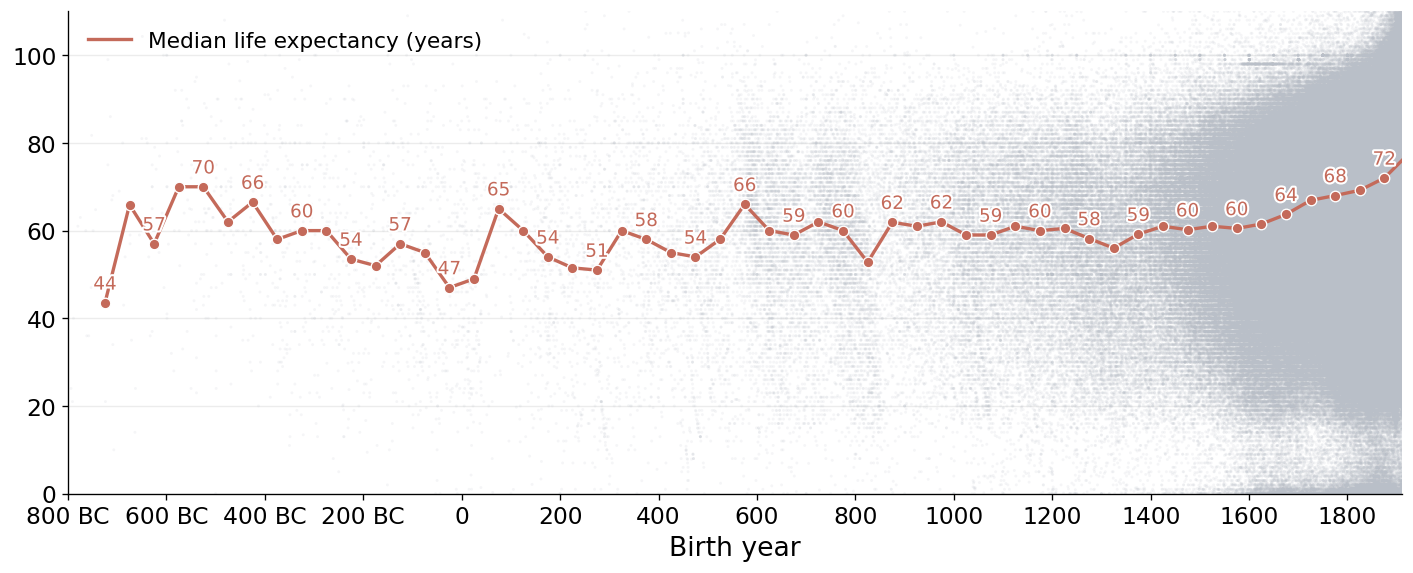

In [8]:
dots = add_birth_bin(life_expectancy).filter(pl.col('birth_year') >= X_MIN)
bins = cohorts('All')

fig, ax = plt.subplots()
ax.scatter(dots['birth_year'], dots['life_expectancy_years'], s=3, color=POINT_CLOUD_COLOR,
           alpha=0.14, edgecolor='none', rasterized=True)
plot_median(ax, bins, HIGHLIGHT_COLOR, 'Median life expectancy (years)')
for i, (x, y) in enumerate(zip(bins['birth_bin'] + BIN_WIDTH / 2, bins['median_life_expectancy'])):
    if i % 2 == 0:
        ax.annotate(f'{y:.0f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center',
                    fontsize=POINT_LABEL_FONTSIZE, color=HIGHLIGHT_COLOR,
                    path_effects=[patheffects.withStroke(linewidth=2.5, foreground=BACKGROUND_COLOR)])
style_axis(ax)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


### Median life expectancy by occupational category

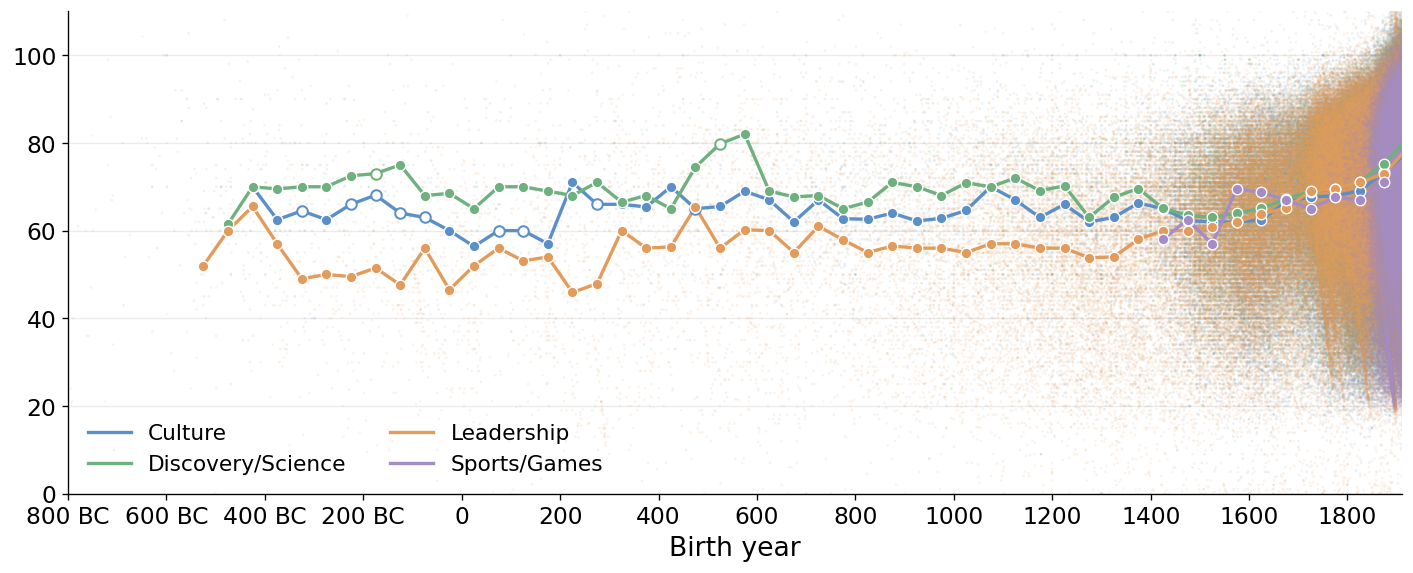

In [9]:
fig, ax = plt.subplots()
for occupation, color in OCCUPATION_COLORS.items():
    people = life_expectancy_with_occupation.filter(
        (pl.col('level1_main_occ') == occupation) & (pl.col('birth_year') >= X_MIN))
    ax.scatter(people['birth_year'], people['life_expectancy_years'], s=2.5, color=color,
               alpha=0.12, edgecolor='none', rasterized=True)

for occupation, color in OCCUPATION_COLORS.items():
    plot_median(ax, cohorts(occupation), color, occupation)

style_axis(ax)
ax.legend(loc='lower left', ncol=2)
plt.tight_layout()
plt.show()
